In [1]:
import pandas as pd
import numpy as np

In [2]:
date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='h')
df = pd.DataFrame(date_rng, columns=['timestamp'])

In [3]:
df['fridge'] = np.random.randint(50, 200, len(df)) * np.random.choice([0,1], len(df), p=[0.3,0.7])

In [4]:
month = df['timestamp'].dt.month
ac_prob = np.where(month >= 4, 0.8, 0.1)
df['ac'] = np.random.randint(1000, 2500, len(df)) * np.random.binomial(1, ac_prob)

In [5]:
hour = df['timestamp'].dt.hour
light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)

df['lights'] = np.random.randint(20, 100, len(df)) * np.random.binomial(1, light_prob)
df['microwave'] = np.random.randint(800, 1200, len(df)) * np.random.choice([0,1], len(df), p=[0.9,0.1])

In [6]:
df['total_power'] = df[['fridge','ac','lights','microwave']].sum(axis=1)
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,86,0,78,0,164
1,2023-01-01 01:00:00,197,0,66,0,263
2,2023-01-01 02:00:00,0,0,78,0,78
3,2023-01-01 03:00:00,90,0,73,0,163
4,2023-01-01 04:00:00,0,0,67,0,67


In [ ]:
#analysis.ipynb

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
#data understanding

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    4321 non-null   datetime64[us]
 1   fridge       4321 non-null   int64         
 2   ac           4321 non-null   int32         
 3   lights       4321 non-null   int32         
 4   microwave    4321 non-null   int64         
 5   total_power  4321 non-null   int64         
dtypes: datetime64[us](1), int32(2), int64(3)
memory usage: 168.9 KB


,timestamp,fridge,ac,lights,microwave,total_power
count,4321,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,2023-04-01 00:00:00,88.317751,776.092803,31.334182,104.025457,999.770192
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-02-15 00:00:00,0.000000,0.000000,0.000000,0.000000,126.000000
50%,2023-04-01 00:00:00,94.000000,0.000000,24.000000,0.000000,943.000000
75%,2023-05-16 00:00:00,148.000000,1644.000000,61.000000,0.000000,1837.000000
max,2023-06-30 00:00:00,199.000000,2498.000000,99.000000,1199.000000,3890.000000
std,NaN,67.638275,909.761469,33.880152,308.181694,957.118144


In [ ]:
## Trend Analysis

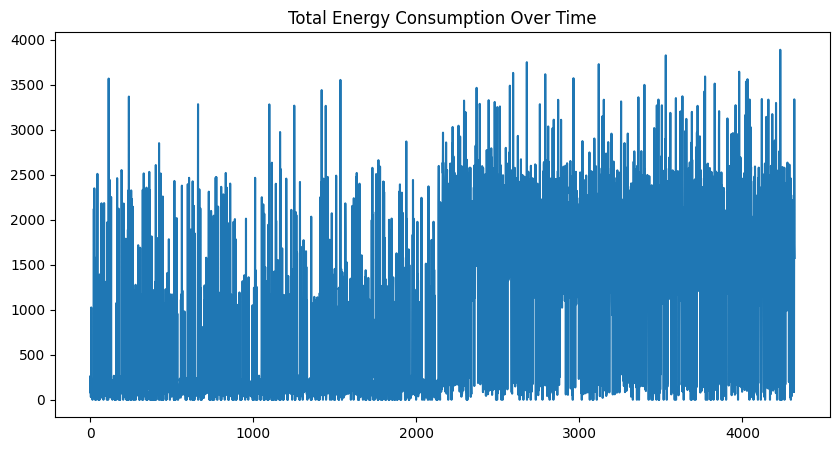

In [9]:
import matplotlib.pyplot as plt

df['total_power'].plot(figsize=(10,5))
plt.title("Total Energy Consumption Over Time")
plt.show()

In [ ]:
## Device Comparison

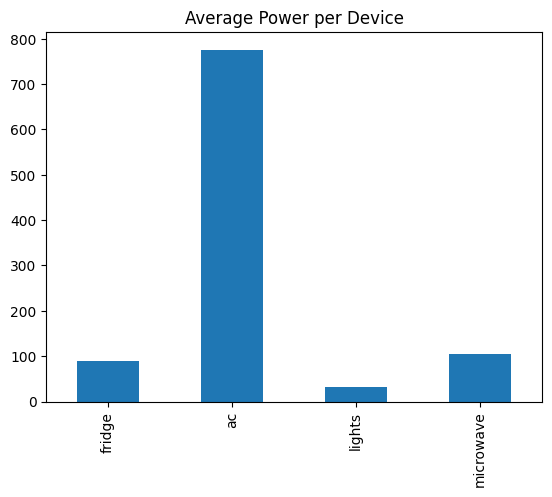

In [10]:
df[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Average Power per Device")
plt.show()

In [ ]:
## Time Analysis

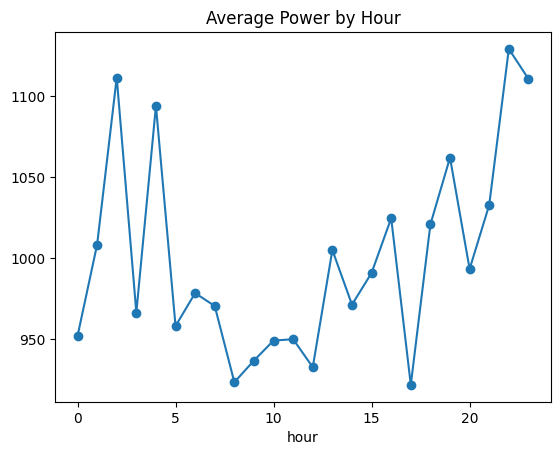

In [11]:
df['hour'] = df['timestamp'].dt.hour

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
## Relationship Analysis

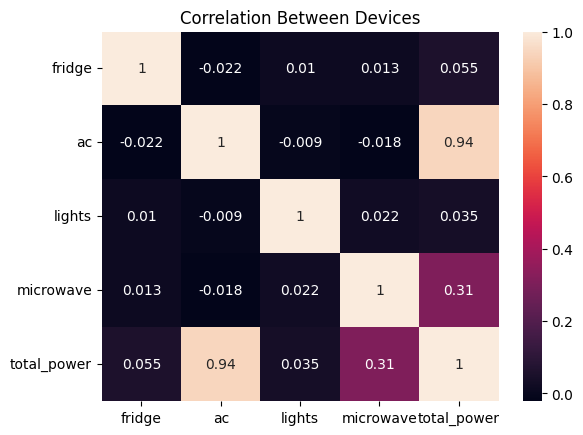

In [12]:
import seaborn as sns

sns.heatmap(df[['fridge','ac','lights','microwave','total_power']].corr(), annot=True)
plt.title("Correlation Between Devices")
plt.show()

In [ ]:
## Time Series Decomposition

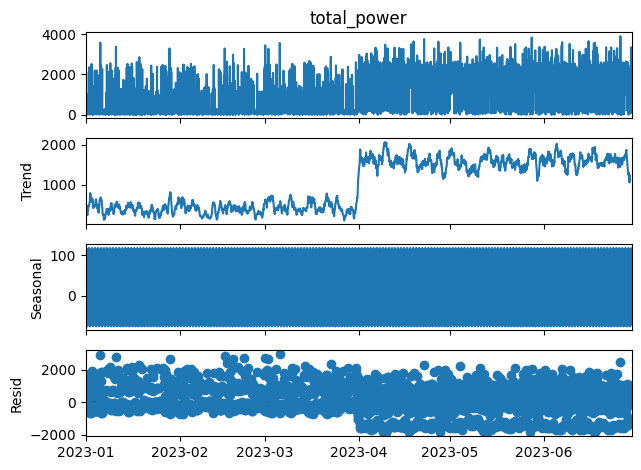

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Decomposition (daily pattern → 24 hours)
decomposition = seasonal_decompose(df['total_power'], model='additive', period=24)

# Plot
decomposition.plot()
plt.show()

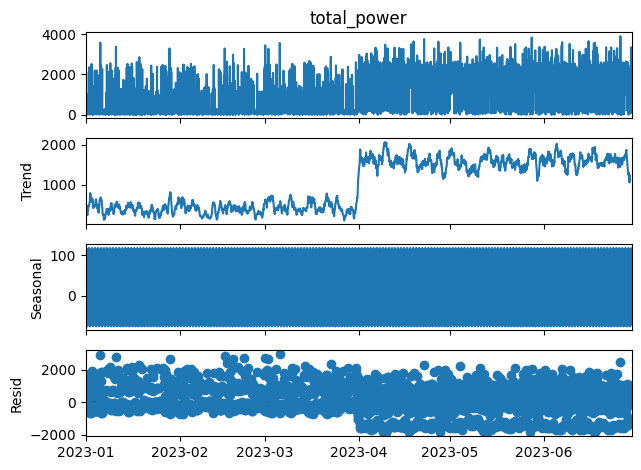

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition using index
result = seasonal_decompose(df['total_power'], model='additive', period=24)

result.plot()
plt.show()

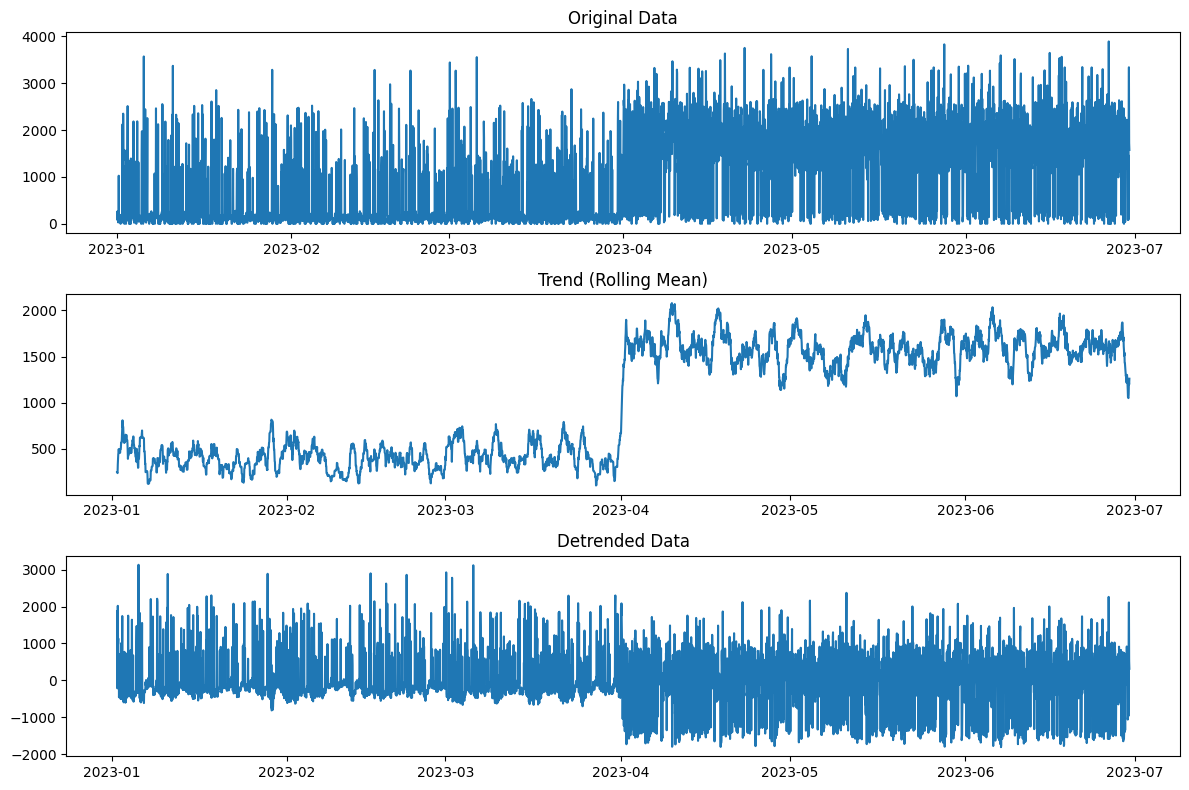

In [15]:
import matplotlib.pyplot as plt

# Make sure timestamp is index
df = df.copy()
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)

# 1. Trend (using rolling mean)
df['trend'] = df['total_power'].rolling(window=24).mean()

# 2. Detrended (remove trend)
df['detrended'] = df['total_power'] - df['trend']

# 3. Plot everything
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(df['total_power'])
plt.title("Original Data")

plt.subplot(3,1,2)
plt.plot(df['trend'])
plt.title("Trend (Rolling Mean)")

plt.subplot(3,1,3)
plt.plot(df['detrended'])
plt.title("Detrended Data")

plt.tight_layout()
plt.show()

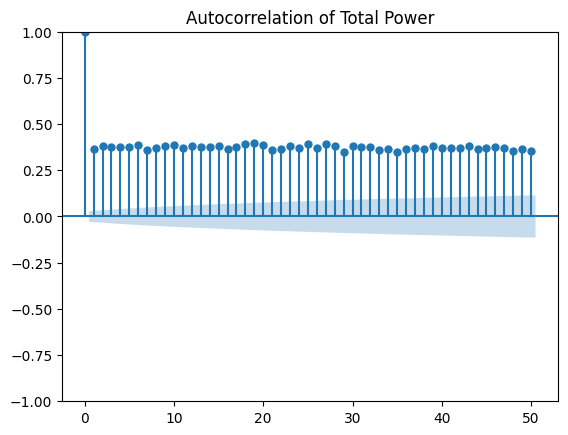

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['total_power'], lags=50)
plt.title("Autocorrelation of Total Power")
plt.show()

In [ ]:
## Partial Autocorrelation (PACF)

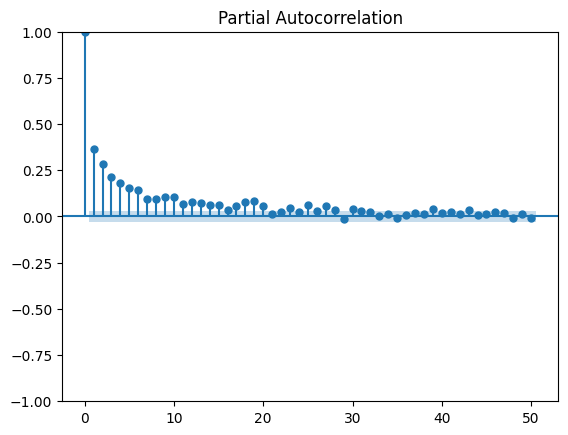

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['total_power'], lags=50)
plt.title("Partial Autocorrelation")
plt.show()

In [ ]:
#hourly.ipynb

In [18]:
df['hour'] = df.index.hour
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended
timestamp,,,,,,,,
2023-01-01 00:00:00,86,0,78,0,164,0,NaN,NaN
2023-01-01 01:00:00,197,0,66,0,263,1,NaN,NaN
2023-01-01 02:00:00,0,0,78,0,78,2,NaN,NaN
2023-01-01 03:00:00,90,0,73,0,163,3,NaN,NaN
2023-01-01 04:00:00,0,0,67,0,67,4,NaN,NaN


In [ ]:
##hourly table

In [19]:
hourly_table = df.groupby('hour').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

hourly_table

total_power                fridge          ac     lights   microwave
             mean   max min        mean        mean       mean        mean
hour                                                                      
0      951.900552  2885   0   87.878453  707.116022  55.602210  101.303867
1     1008.416667  3253   0   87.077778  756.277778  49.450000  115.611111
2     1111.622222  3828   0   85.927778  847.988889  53.961111  123.744444
3      966.411111  3593   0   87.355556  735.327778  54.827778   88.900000
4     1094.150000  3442  24   82.288889  836.977778  50.672222  124.211111
5      958.133333  3337   0   90.761111  731.705556  55.616667   80.050000
6      978.477778  3491   0   89.822222  756.161111  54.050000   78.444444
7      970.477778  3618   0   90.677778  768.822222   5.400000  105.577778
8      923.405556  3890   0   80.955556  722.955556   6.283333  113.211111
9      936.788889  3310   0   81.072222  759.711111   7.316667   88.688889
10     949.138889  2951   0   87.505556  764.044444   6.183333   91.405556
11     949.966667  3167   0   87.594444  790.838889   4.633333   66.900000
12     932.672222  3574   0   88.988889  744.405556   5.222222   94.055556
13    1005.066667  3325   0   97.327778  798.966667   5.661111  103.111111
14     971.322222  3752   0   87.105556  750.005556   4.188889  130.022222
15     990.927778  3500   0   83.300000  771.238889   3.844444  132.544444
16    1024.727778  3353   0   93.277778  827.933333   5.700000   97.816667
17     921.738889  3260   0   85.733333  743.461111   5.894444   86.650000
18    1020.894444  3570   0   90.572222  771.700000  48.438889  110.183333
19    1062.133333  3283   0   96.816667  794.761111  57.422222  113.133333
20     993.366667  3646   0   91.666667  737.711111  55.550000  108.438889
21    1032.888889  2955   0   81.750000  828.550000  54.638889   67.950000
22    1129.288889  3370   0   83.816667  859.288889  48.488889  137.694444
23    1110.833333  3730   0  100.355556  820.661111  52.838889  136.977778

In [ ]:
##average power by hour

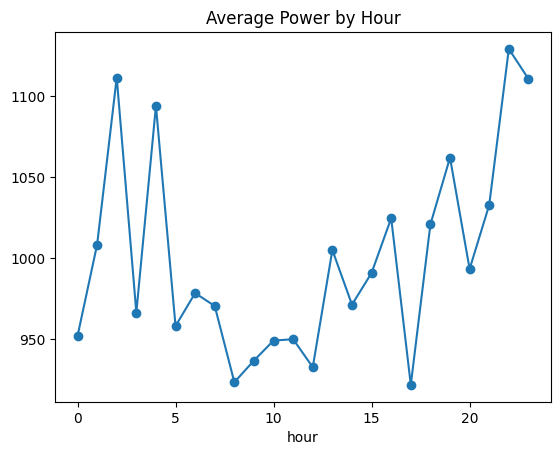

In [20]:
import matplotlib.pyplot as plt

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
##maximum power by hour

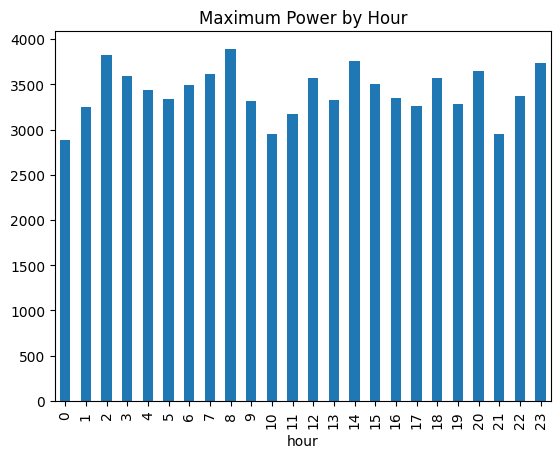

In [21]:
df.groupby('hour')['total_power'].max().plot(kind='bar')
plt.title("Maximum Power by Hour")
plt.show()

In [ ]:
##minimum power by hour

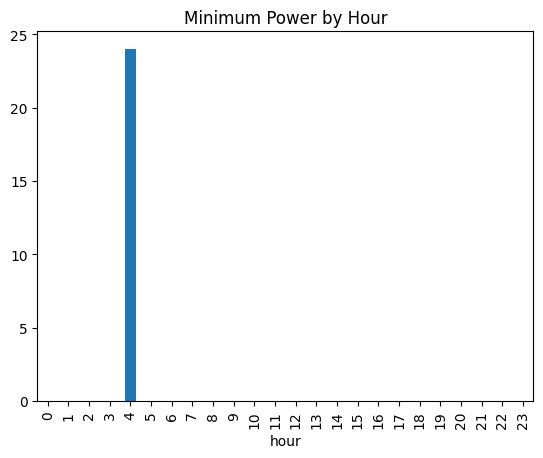

In [22]:
df.groupby('hour')['total_power'].min().plot(kind='bar')
plt.title("Minimum Power by Hour")
plt.show()

In [ ]:
##Device-wise Hourly Usage

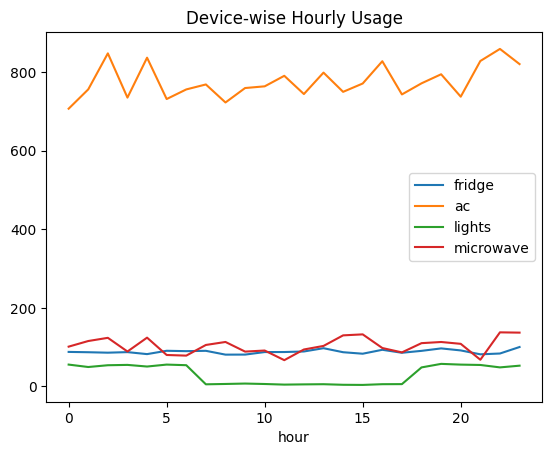

In [23]:
df.groupby('hour')[['fridge','ac','lights','microwave']].mean().plot()
plt.title("Device-wise Hourly Usage")
plt.show()

In [ ]:
##Peak Hour Detection

In [24]:
peak_hour = df.groupby('hour')['total_power'].mean().idxmax()
print("Peak usage hour:", peak_hour)

Peak usage hour: 22


In [ ]:
##weekly.ipynb

In [25]:
df['day_type'] = df.index.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type
timestamp,,,,,,,,,
2023-01-01 00:00:00,86,0,78,0,164,0,NaN,NaN,Weekend
2023-01-01 01:00:00,197,0,66,0,263,1,NaN,NaN,Weekend
2023-01-01 02:00:00,0,0,78,0,78,2,NaN,NaN,Weekend
2023-01-01 03:00:00,90,0,73,0,163,3,NaN,NaN,Weekend
2023-01-01 04:00:00,0,0,67,0,67,4,NaN,NaN,Weekend


In [ ]:
##weeday vs weekend

In [26]:
daytype_table = df.groupby('day_type').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

daytype_table

total_power               fridge          ac     lights   microwave
                 mean   max min       mean        mean       mean        mean
day_type                                                                     
Weekday    995.783016  3890   0  89.520827  771.578947  31.561188  103.122054
Weekend   1009.858660  3828   0  85.273693  787.513889  30.759804  106.311275

In [ ]:
##Compare Total Power

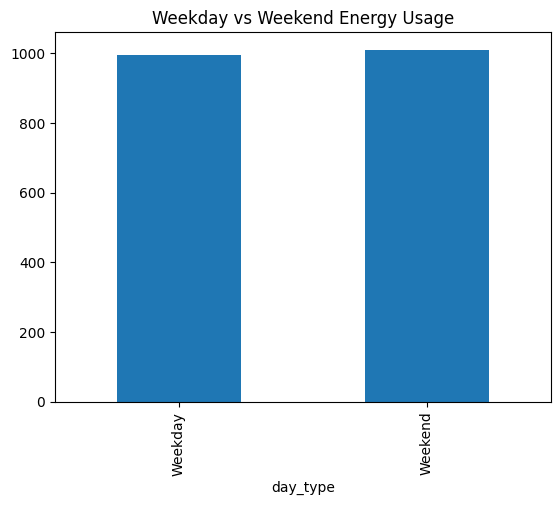

In [27]:
import matplotlib.pyplot as plt

df.groupby('day_type')['total_power'].mean().plot(kind='bar')
plt.title("Weekday vs Weekend Energy Usage")
plt.show()

In [ ]:
##Hourly Pattern for Weekday vs Weekend

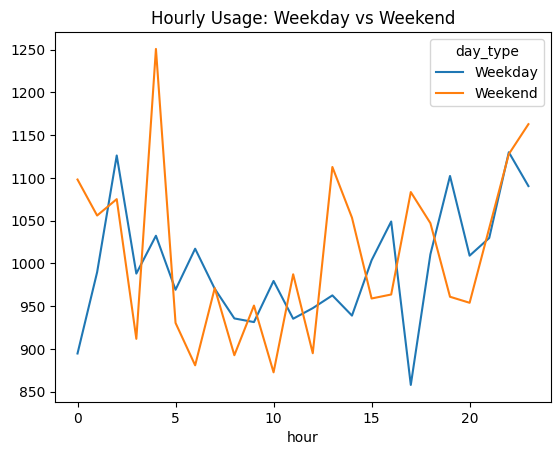

In [28]:
df['hour'] = df.index.hour

df.groupby(['hour','day_type'])['total_power'].mean().unstack().plot()
plt.title("Hourly Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Device-wise Comparison

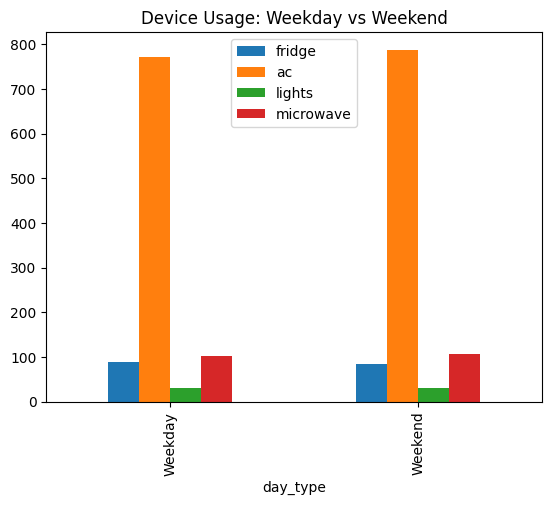

In [29]:
df.groupby('day_type')[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Device Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Peak Time (Weekday vs Weekend) 

In [30]:
peak = df.groupby(['hour','day_type'])['total_power'].mean().reset_index()

weekday_peak = peak[peak['day_type']=='Weekday'].sort_values('total_power', ascending=False).iloc[0]
weekend_peak = peak[peak['day_type']=='Weekend'].sort_values('total_power', ascending=False).iloc[0]

print("Weekday Peak Hour:", weekday_peak['hour'])
print("Weekend Peak Hour:", weekend_peak['hour'])

Weekday Peak Hour: 22
Weekend Peak Hour: 4


In [ ]:
##Energy Difference (Insight Program)

In [31]:
weekday_avg = df[df['day_type']=='Weekday']['total_power'].mean()
weekend_avg = df[df['day_type']=='Weekend']['total_power'].mean()

print("Weekday Avg:", weekday_avg)
print("Weekend Avg:", weekend_avg)
print("Difference:", weekend_avg - weekday_avg)

Weekday Avg: 995.783015821763
Weekend Avg: 1009.8586601307189
Difference: 14.07564430895593


In [ ]:
##monthly.ipynb

In [32]:
df['month'] = df.index.month
df['month_name'] = df.index.month_name()
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type,month,month_name
timestamp,,,,,,,,,,,
2023-01-01 00:00:00,86,0,78,0,164,0,NaN,NaN,Weekend,1,January
2023-01-01 01:00:00,197,0,66,0,263,1,NaN,NaN,Weekend,1,January
2023-01-01 02:00:00,0,0,78,0,78,2,NaN,NaN,Weekend,1,January
2023-01-01 03:00:00,90,0,73,0,163,3,NaN,NaN,Weekend,1,January
2023-01-01 04:00:00,0,0,67,0,67,4,NaN,NaN,Weekend,1,January


In [ ]:
##Monthly Summary Table 

In [33]:
monthly_table = df.groupby('month_name').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

monthly_table

total_power               fridge           ac     lights  \
                   mean   max min       mean         mean       mean   
month_name                                                             
April       1606.815278  3752   0  87.186111  1388.891667  30.358333   
February     373.041667  3283   0  88.745536   149.654762  33.464286   
January      404.565860  3570   0  90.967742   184.174731  31.263441   
June        1605.097561  3890   0  85.659971  1382.428981  30.542324   
March        450.116935  3555   0  91.143817   205.973118  32.419355   
May         1556.154570  3828   0  86.040323  1342.881720  30.081989   

             microwave  
                  mean  
month_name              
April       100.379167  
February    101.177083  
January      98.159946  
June        106.466284  
March       120.580645  
May          97.150538

In [ ]:
##Total Power by Month

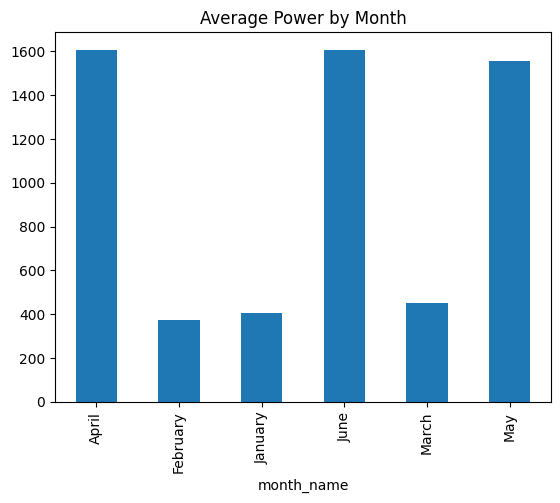

In [34]:
import matplotlib.pyplot as plt

df.groupby('month_name')['total_power'].mean().plot(kind='bar')
plt.title("Average Power by Month")
plt.show()

In [ ]:
##Compare Few Months

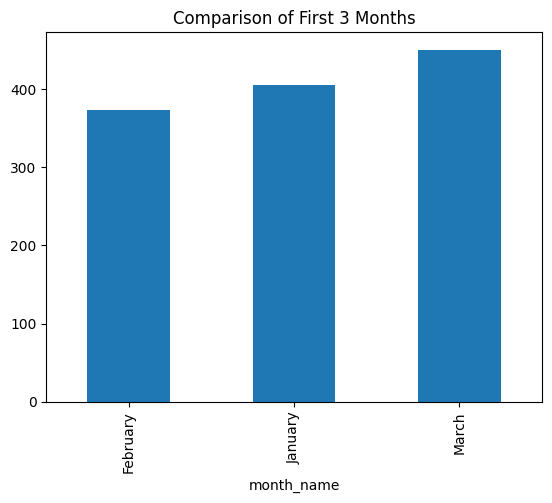

In [35]:
selected_months = ['January','February','March']

df[df['month_name'].isin(selected_months)] \
.groupby('month_name')['total_power'].mean() \
.plot(kind='bar')

plt.title("Comparison of First 3 Months")
plt.show()

In [ ]:
##Device Usage for Few Months 

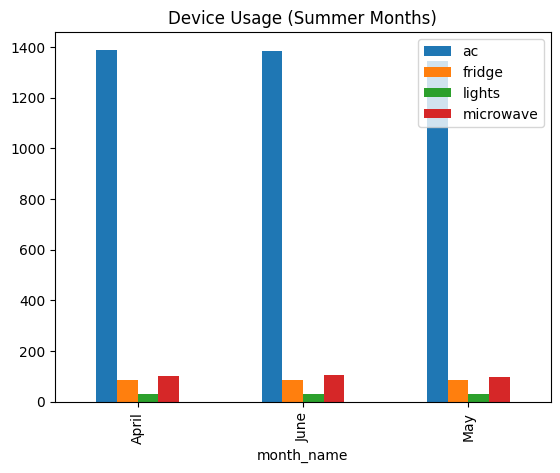

In [36]:
df[df['month_name'].isin(['April','May','June'])] \
.groupby('month_name')[['ac','fridge','lights','microwave']] \
.mean().plot(kind='bar')

plt.title("Device Usage (Summer Months)")
plt.show()

In [ ]:
##Monthly Peak Detection

In [37]:
peak_month = df.groupby('month_name')['total_power'].mean().idxmax()
print("Peak usage month:", peak_month)

Peak usage month: April


In [ ]:
##Monthly Trend Line 

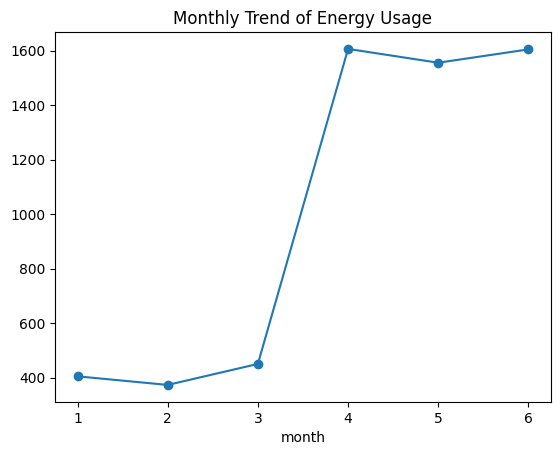

In [38]:
df.groupby('month')['total_power'].mean().plot(marker='o')
plt.title("Monthly Trend of Energy Usage")
plt.show()

In [ ]:
##Winter vs Summer comparison

In [39]:
winter = ['January','February','March']
summer = ['April','May','June']

print("Winter Avg:", df[df['month_name'].isin(winter)]['total_power'].mean())
print("Summer Avg:", df[df['month_name'].isin(summer)]['total_power'].mean())

Winter Avg: 410.44814814814816
Summer Avg: 1588.8195279962981


In [ ]:
## AC usage increase

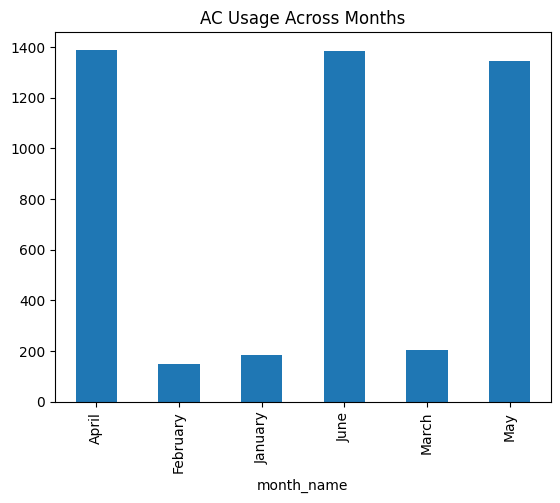

In [40]:
df.groupby('month_name')['ac'].mean().plot(kind='bar')
plt.title("AC Usage Across Months")
plt.show()

In [ ]:
##polynomial.ipynb

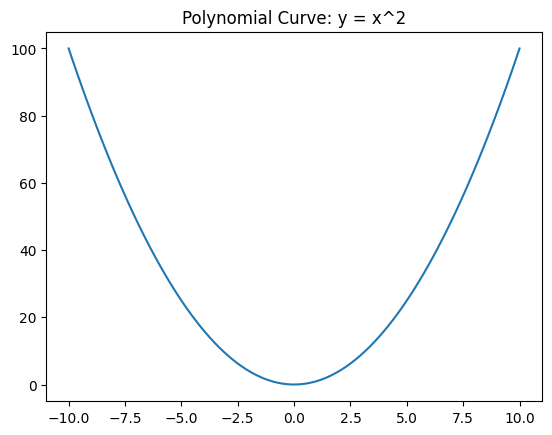

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x**2

plt.plot(x, y)
plt.title("Polynomial Curve: y = x^2")
plt.show()

In [ ]:
##multiple polynomial curves

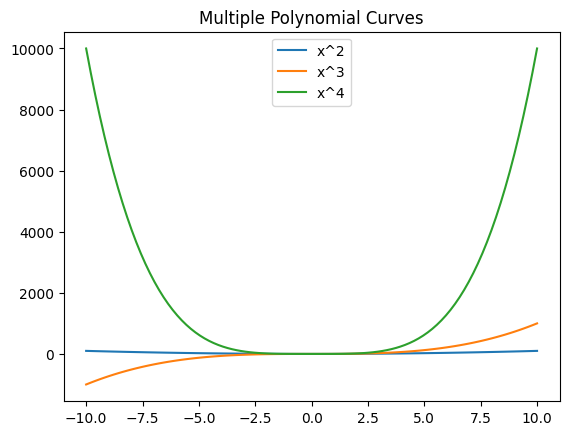

In [42]:
x = np.linspace(-10, 10, 100)

plt.plot(x, x**2, label="x^2")
plt.plot(x, x**3, label="x^3")
plt.plot(x, x**4, label="x^4")

plt.legend()
plt.title("Multiple Polynomial Curves")
plt.show()

In [ ]:
##polynomial regression 

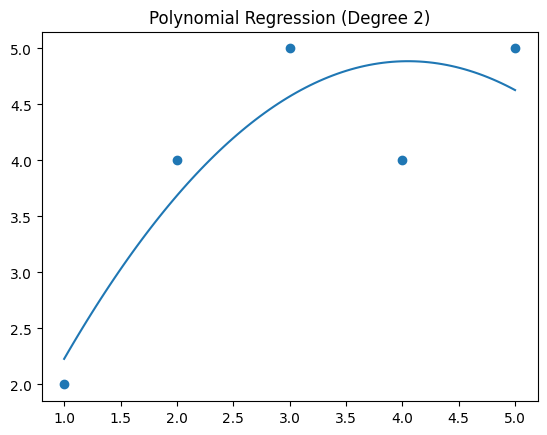

In [43]:
# sample data
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

# fit polynomial (degree 2)
coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

# plot
x_new = np.linspace(1,5,100)
plt.scatter(x, y)
plt.plot(x_new, poly(x_new))
plt.title("Polynomial Regression (Degree 2)")
plt.show()

In [ ]:
##compare linear vs polynomial regression

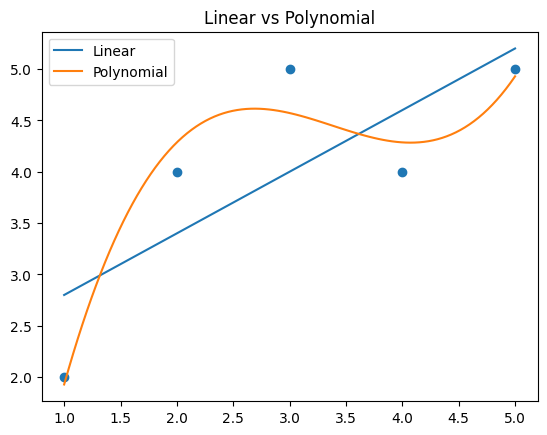

In [44]:
# linear fit
linear = np.polyfit(x, y, 1)
linear_fn = np.poly1d(linear)

# polynomial fit
poly = np.polyfit(x, y, 3)
poly_fn = np.poly1d(poly)

plt.scatter(x, y)
plt.plot(x_new, linear_fn(x_new), label="Linear")
plt.plot(x_new, poly_fn(x_new), label="Polynomial")

plt.legend()
plt.title("Linear vs Polynomial")
plt.show()

In [ ]:
prediction.ipynb

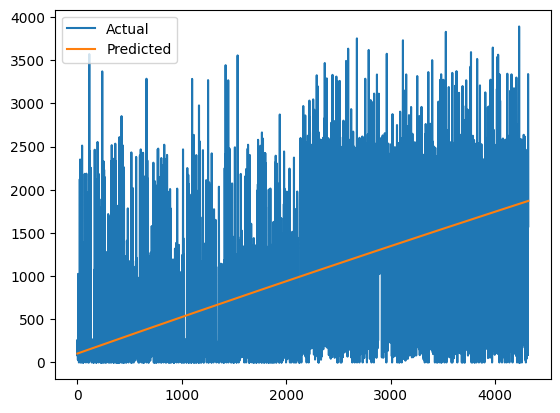

In [45]:
# Predict energy trend using polynomial
x = np.arange(len(df))
y = df['total_power']

coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

plt.plot(x, y, label="Actual")
plt.plot(x, poly(x), label="Predicted")

plt.legend()
plt.show()